AUTOENCODER CLASSICO: FONDAMENTA E LIMITI

Capire come una macchina impare a distillare l essenza dei dati e capire come questo processo, pur essendo potente, non basta per craere una vera intelligenza generativa.
L'autoencoder classico non è, di per se, un buon modello generativo

- Limidi di Generalizzazione: perchè autoencoder standard è solo un ottimo archivista ma un pessimo sognatore
- Compressione Lossy
- Utilizzo non Generativo: L'autoencoder utilizzato per: 1) come versione evoluta della classica PCA. 2) come anomaly detection (rilevamento comportamenti anomali). 3) denoising: partendo da un immagine 'sporca' per arrivare all'immagine 'pulita'

Perchè non riusciamo a generare dati nuovi con un modello classico?
L'autoencoder è una macchina speculare. 
Prende un input, lo schiaccia in un imbuto e cerca di ricostruirlo dall'altra parte.
E' un esercizio di auto-riproduzione. Il problema è che se non stiamo attenti la rete diventa brava a fare il pappagallo, invece di capire le regole di un volto, impara a memoria i pixel, si comporta come uno studente che impara e memoria senza capire la materia.

Un autoencoder classico è formato da due parti:
- Encoder: trasforma l'input (x) in un vettore latente (z)
- Decoder: prende z e cerca di ricostruire x
z (latent space) non è una memoria, è una rappresentazione numerica compressa delle caratteristiche considerate utile alla ricostruzione.
Immagine originale 28x28=748 valori (x) -> Encoder porta a 128 valori -> Encoder porta a 32 valori -> Encoder porta a 2 valori (z) -> Decoder porta a 32 valori -> Decoder poirta a 128 valori -> Decoder porta a 784 valori (28x28), ricostruzione immagine originale
784->128->32->2->32->128->784 è il latent space
Costringendo il modello a rappresentare 784 valori in solo 2 numeri, deve imparare quali caratteristiche sono veramente importanti.
Questo il motivo per cui un autoencodere classico può fare dimensionality reduction.
L'autoencoder non ha bisogno di etichette, è un apprendimento non supervisionato (self-supervised), il target è lo stesso input.

La funzione di costo misura quanto la ricostruzione differisce dall'originale.
Per dati continui comunemente si usa MSE (Mean Squared Error)


Cosa accade tecnicamente in questo processo di memorizzazione rigida.
Il grande problema, la discontinuità

Overfitting e Discontinuità
I buchi nello spazio letente.
Un AutoEncoder (AE) classico impara a mappare l'input in un punto esatto 'z' dello spazio latente, senza considerare l'area circostante.
Immagina lo spazio latente come un oceano con tante piccole isole, ogni isola è un dato del training set, se proviamo ad atterrare con il Decoder esattamente su un isola abbiamo una ricostruzione perfetta, ma se atterriamo tra le acque tra due isole, ovvero in una zona mai vista, il decoder produrrà solo rumore. 
La nostra funzione di costo guarda solo alla fedeltà dei pixel, ma non le importa nulla di come queste isole siano collegate, non ci sono ponti tra i concetti.
L'autoencoder sa fare bene x reale -> encoder -> z conosciuto -> decoder -> ricostruzione
Ma non necessariamente z casuale -> decoder -> nuovo dato realistico (non adatto alla parte generativa). Ed è qui che entra in gioco il VAE (che vedremo dopo)
Attenzione: il latent space (z) non ha automaticamente un significato umano leggibile.

Questo ci porta ad interrogarci sulla natura del Manifold dei dati
Se il nostro collo di bottiglia (bottleneck) è troppo largo, la rete impara la funzione identità copiando i pixel senza estrarre feature utili (ricordiamo che l'ai è pigra ed impara a memoria quando può).
Ogni immagine diventa un isola isolata, rendendo l'ai un sistema di archiviazione avanzato
Impostando il bottleneck a 2 o 3 dimensioni, possiamo proiettare dataset complessi in uno spazio visibile per l'analisi umana (rappresentazioni discrete).
Non esiste una definizione probabilistica di 'z'; non sappiamo quale sia la probabilità che un punto latente appartenga ai dati reali.
Non sappiamo cosa ci siamo vicino ad un gatto nello spazio latente.
Perchè non abbiamo impostato una distribuzione.
E' un sistema deterministico puro: un input, un punto, un output. Nessuna sfumatura, nessuna creatività.

Proviamo a visualizzare questo deserto informativo tra i dati

Visualizzare la Discontinuità
Il limite del determinismo
Analizzando graficamente lo spazio latente di un AE, notiamo ampie zono vuote tra i cluster delle classi.
Le classi sono clusterizzate ma separate da zone di vuoto.
Questa natura deterministica è ciò che distingue l'AE dai modelli generativi che vi sono susseguiti, dove lo spazio latente sarà forzato a essere compatto.
L'AE definisce solo una mappa tra due spazi ma non definisce come muoversi tra di essi, se volessi generare un volto tra due volti, l'autoencoder fallirà, perchè non ha mai imparato cosa sia un volto in termini di probabilità. Questo è dato dal latent space dicontinuo (tra due volti ho del vuoto, non ho dei collegamenti)
Il VAE (che vedremo a breve) cerca di rendere lo spazio latente continuo e strutturato

Meccanica che rende utile questo modello: il bottleneck

Compressione Lossy
Il collo di bottiglia informativo
Il cuore dell'Autoencoder (AE) è il bottleneck: una restrizione forzata della capacità della rete che obbliga il sistema a scartare le  informazioni ridondanti.
Schiacciamo l'imbuto al centro, perchè vogliamo forza una compressione lossy, ovver con perdita. Se permettessimo alla rete di far passare tutte le informazioni, allora si che non imparerebbe nulla, limitando la capacità, obblighiamo la rete a fare una scelta.

Quali sono le informazioni vitali, e quali sono rumore?
E' come quando devi raccontare la trama di un film di 3 ore in 30 secondi, scarti il colore della scarpe del protagonista, ma tieni la scena finale.

Vediamo come questa distillazione avviene fisicamente.

Dimensione del Bottleneck
La dimensione del bottleneck è il nostro regolatore di essenza, determina quanta varianza del dataset originale, può essere preservata dai layer convoluzonali o densi.
Un bottleneck stretto agisce come un regolarizzatore, forzando la rete a imparare le strutture globali invece dei dettagli locali.
Non può sprecare neuroni per moemorizzare un singolo pixel sporco.
Questa perdita è in realtà un vantaggio, ci permette di ottenere una rappresentazione densa, dove ogni numero rappresenta una feature significativa del dataset originale.
La perdita di informazioni (reconstruction error) è il prezzo da pagare per ottenere una rappresentazione densa o utile.
Il trade-off tra fedeltà e compressione è il parametro ingegneristico fondamentale per ottimizzare queste architetture.

Ma come valutiamo la bontà di questa ricostruzione sfuocata?

Qualità di Ricostruzione
MSE dato dalle differenze tra l'immagine originale e quella ricostruita.
L'uso dell'Errore Quadratico Medio (MSE) tende a produrre ricostruzioni leggermente sfocate, poichè la rete cerca di minimizzare la media degli scarti per pixel.
Encoder e Decoder devono avere capacità bilanciate; un decoder troppo potente potrebbe 'inventare' dettagli non presenti nel codice latente.
Se diamo troppa potenza all'autoencoder, questo potrebbe inventarsi dettagli che non esistono.
Le attivazioni che otteniamo in questo imbuto, sono preziose, possono essere usate come input per un classificatore, rendendo il lavoro molto più semplice perchè i dati sono già stati puliti e classificati.

C'è un legame profonodo tra questo processo e la teoria dell'informazione
Analisi del Rapport di Compressione
Entropia e Bottleneck
Con l'autoencoder vogliamo massimizzare quanto il nostro codice z ci dice del dato x.
All'inizio aumentando la dimensione del bottleneck la qualità migliora drasticamente, dopo un certo punto i benefici diminuiscono.
Questo ci dice che abbiamo estratto tutta l'essenza possibile e stiamo iniziando ad includere rumore.
Trovare questo punto di equilibrio è l'arte del deep learning architect.

Ma se l'autoencoder non può generare perchè continuiamo ad usarlo massicciamente nell'industria?

Utilizzo non Generativo
Riduzione della dimensionalità e Denoising

Sebbende l'AE classico fallisca nella generazione di nuovi campioni, eccelle in compiti di utilità pratica come la pulizia dei dati e la visualizzazione.
L'AE può essere quindi considerato come un'estensione non lineare della Principal Component Analysis (PCA)

Se hai dati troppo complessi o troppo sporchi l'AE è un alleato per portare l'ordine nel caos.

PCA non lineare.
Mappare variatà complesse.
Mentra la PCA classica è ottima ma limitata a proiezioni lineari, l'AE può apprendere superfici di proiezione curve (manifold) grazie alla funzione di attivazione.
L'AE è una PCA non lineare, può imparare superfici curve o origami di dati complessi.
Un'applicazione straordinaria è il Denoising.
Il Denoising Autoencoder impara a rimuovere rumore stocastico forzando la rete a ricostuire il dato pulito da un input corrotto.
Input: immagine sporca; Output: immagine pulita ricostruita.
In questo modo la rete impara a ignorare il ruomore, focalizzandosi solo sulla struttura sottostante.
Questi modelli sono estremamente robusti per l'estrazione di feature in contesti industriali dove i sensori producono dati sporchi.
L'AE classico è lo strumento d'elezione per pre-processare dataset ad alta dimensionalità prima di algoritmi di clustering.

Vediamo come questo si traduce in valore pratico

Applicazioni Pratiche
- Anomaly Detection (basata su AE): se un input produce un errore di ricostruzione molto alto, significa che è un outlier non appartenente alla distribuzione di trainig. Se addestriamo la rete su dati corretti, quando arriva un dato anomalo, la rete non saprà come ricostruirlo, un errore di ricostuzione altissimo è il nostro segnale d'allarme.
- Visualizzazione 2D/3D: impostando il bottleneck a solo 2 o 3 dimensioni, possiamo proiettare dataset complessi in uno spazio visibile per l'analisi umana. individuando classer e pattern che altrimenti rimarrebbero invisibili in migliaia di dimensioni.
- Data Cleaning: l'architettura può essere usata per riparare immagini danneggiate o segnali audio con drop-out.

Confronto AE vs PCA
Se usassimo solo attivazioni lineari l'AE troverebbe lo stesso sottospazio individuato dalla PCA (non farebbe nulla di più).
L'introduzione di layer profondi e funzioni come ReLU permette di catturare dipendenze gerarchiche che la PCA ignorerebbe totalmente.

Inizio addestramento Autoencoder...
Epoca [50], Loss: 0.2069
Epoca [100], Loss: 0.0609
Epoca [150], Loss: 0.0451
Epoca [200], Loss: 0.0421
Epoca [250], Loss: 0.0404
Epoca [300], Loss: 0.0391
Epoca [350], Loss: 0.0381
Epoca [400], Loss: 0.0373
Epoca [450], Loss: 0.0367
Epoca [500], Loss: 0.0364
Epoca [550], Loss: 0.0361
Epoca [600], Loss: 0.0359
Epoca [650], Loss: 0.0357
Epoca [700], Loss: 0.0355
Epoca [750], Loss: 0.0353
Epoca [800], Loss: 0.0352
Epoca [850], Loss: 0.0350
Epoca [900], Loss: 0.0349
Epoca [950], Loss: 0.0347
Epoca [1000], Loss: 0.0346
Epoca [1050], Loss: 0.0344
Epoca [1100], Loss: 0.0343
Epoca [1150], Loss: 0.0341
Epoca [1200], Loss: 0.0339
Epoca [1250], Loss: 0.0338
Epoca [1300], Loss: 0.0336
Epoca [1350], Loss: 0.0335
Epoca [1400], Loss: 0.0335
Epoca [1450], Loss: 0.0334
Epoca [1500], Loss: 0.0333
Epoca [1550], Loss: 0.0332
Epoca [1600], Loss: 0.0332
Epoca [1650], Loss: 0.0331
Epoca [1700], Loss: 0.0331
Epoca [1750], Loss: 0.0330
Epoca [1800], Loss: 0.0329
Epoca [1850]

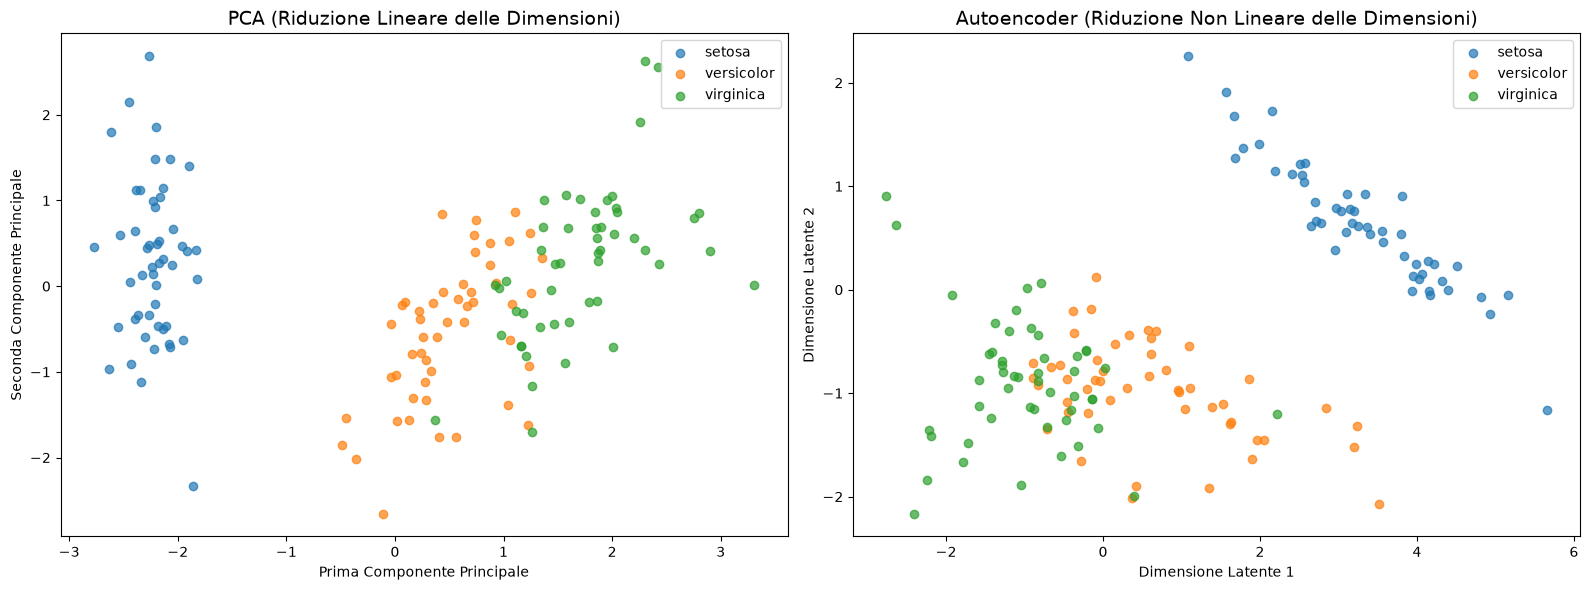

In [ ]:
#********************************************************
# *** Utilizzo dell'AE come strumento di riduzione dimensionalità ***
#********************************************************

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Inizializzazione e preparazione dei dati
# Il dataset Iris contiene 4 caratteristiche per ogni fiore. L'obiettivo e' ridurre queste 4 dimensioni a 2.
iris = load_iris()
X = iris.data  # Matrice delle caratteristiche (150 campioni, 4 feature)
y = iris.target  # Etichette delle classi (Setosa, Versicolor, Virginica)
target_names = iris.target_names

# La standardizzazione e' necessaria perche' sia la PCA che l'Autoencoder sono sensibili alla scala dei dati.
# Trasformiamo i dati in modo che abbiano media 0 e deviazione standard 1.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convertiamo i dati in un tensore PyTorch per darli in pasto alla rete neurale dell'Autoencoder.
X_tensor = torch.FloatTensor(X_scaled)

# --- FASE A: PCA (Principal Component Analysis) ---
# La PCA e' una tecnica lineare. Cerca le direzioni (componenti principali) che mantengono la massima varianza.
# Qui riduciamo direttamente le 4 dimensioni originali a 2 componenti principali.
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# --- FASE B: Autoencoder (Rete Neurale per Riduzione Non Lineare) ---
# Definiamo la struttura dell'autoencoder ereditando da nn.Module di PyTorch.
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        # L'Encoder comprime l'input.
        # Passiamo da 4 feature a 8 intermedie, poi a 2 (spazio latente o bottleneck).
        # L'obiettivo e' forzare la rete a imparare una rappresentazione compressa ma significativa.
        self.encoder = nn.Sequential(
            nn.Linear(4, 8),   # Strato lineare: input 4 -> output 8
            nn.ReLU(),         # Funzione di attivazione non lineare per catturare relazioni complesse
            nn.Linear(8, 2)    # Strato finale dell'encoder: output 2 (le nostre nuove coordinate)
        )
        
        # Il Decoder tenta di ricostruire i dati originali partendo dalle 2 dimensioni compresse.
        # Se la ricostruzione e' accurata, significa che le 2 dimensioni contengono le info essenziali.
        self.decoder = nn.Sequential(
            nn.Linear(2, 8),   # Espansione: 2 -> 8
            nn.ReLU(),         # Attivazione
            nn.Linear(8, 4)    # Ritorno alle 4 dimensioni originali
        )

    def forward(self, x):
        # Il metodo forward definisce il flusso dei dati attraverso la rete.
        encoded = self.encoder(x)   # Fase di compressione
        decoded = self.decoder(encoded)  # Fase di ricostruzione
        return encoded, decoded

# Inizializzazione del modello e degli strumenti di ottimizzazione
model = Autoencoder()
# MSELoss (Mean Squared Error) misura la differenza tra l'input originale e la ricostruzione del decoder.
criterion = nn.MSELoss()
# Adam e' l'algoritmo che modifica i pesi della rete per minimizzare l'errore (loss).
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Ciclo di addestramento (Training Loop)
print("Inizio addestramento Autoencoder...")
for epoch in range(5000):
    # Passaggio in avanti (Forward pass): otteniamo la rappresentazione compressa e quella ricostruita.
    encoded, decoded = model(X_tensor)
    
    # Calcolo dell'errore confrontando la ricostruzione con i dati originali standardizzati.
    loss = criterion(decoded, X_tensor)
    
    # Fase di ottimizzazione:
    optimizer.zero_grad()  # Reset dei gradienti dai cicli precedenti
    loss.backward()        # Calcolo del gradiente tramite backpropagation
    optimizer.step()       # Aggiornamento dei pesi della rete
    
    # Stampa del progresso ogni 50 epoche
    if (epoch + 1) % 50 == 0:
        print(f'Epoca [{epoch+1}], Loss: {loss.item():.4f}')

# Estrazione dello spazio latente (le coordinate ridotte a 2 dimensioni)
# Usiamo torch.inference_mode() per disabilitare il calcolo del gradiente e risparmiare memoria.
with torch.inference_mode():
    X_ae, _ = model(X_tensor)
    X_ae = X_ae.numpy()  # Convertiamo il tensore in array NumPy per la visualizzazione

# --- FASE C: Visualizzazione e Confronto ---
# Creiamo due grafici affiancati per confrontare i risultati della PCA e dell'Autoencoder.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Cicliamo sulle tre classi di Iris per assegnare colori diversi nel plot.
for i, color in zip(range(len(target_names)), colors):
    # Visualizzazione PCA: proiezione lineare classica.
    mask = (y == i)
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], color=color, label=target_names[i], alpha=0.7)
    
    # Visualizzazione Autoencoder: proiezione basata sul bottleneck della rete neurale.
    ax2.scatter(X_ae[mask, 0], X_ae[mask, 1], color=color, label=target_names[i], alpha=0.7)

# Configurazione estetica del grafico PCA
ax1.set_title("PCA (Riduzione Lineare delle Dimensioni)", fontsize=14)
ax1.set_xlabel("Prima Componente Principale")
ax1.set_ylabel("Seconda Componente Principale")
ax1.legend()

# Configurazione estetica del grafico Autoencoder
ax2.set_title("Autoencoder (Riduzione Non Lineare delle Dimensioni)", fontsize=14)
ax2.set_xlabel("Dimensione Latente 1")
ax2.set_ylabel("Dimensione Latente 2")
ax2.legend()

plt.tight_layout()
plt.show()